In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    log_loss
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

import math

In [2]:
root_dir_pf7 = "../data/pf7/" 

In [3]:
metadata_df = pd.read_csv(
    root_dir_pf7 + "Pf7_samples.txt",
    sep="\t"
)

metadata_df.head()

,Sample,Study,Country,Admin level 1,Country latitude,Country longitude,Admin level 1 latitude,Admin level 1 longitude,Year,ENA,All samples same case,Population,% callable,QC pass,Exclusion reason,Sample type,Sample was in Pf6
0,FP0008-C,1147-PF-MR-CONWAY,Mauritania,Hodh el Gharbi,20.265149,-10.337093,16.565426,-9.832345,2014.0,ERR1081237,FP0008-C,AF-W,82.16,True,Analysis_set,gDNA,True
1,FP0009-C,1147-PF-MR-CONWAY,Mauritania,Hodh el Gharbi,20.265149,-10.337093,16.565426,-9.832345,2014.0,ERR1081238,FP0009-C,AF-W,88.85,True,Analysis_set,gDNA,True
2,FP0010-CW,1147-PF-MR-CONWAY,Mauritania,Hodh el Gharbi,20.265149,-10.337093,16.565426,-9.832345,2014.0,ERR2889621,FP0010-CW,AF-W,86.46,True,Analysis_set,sWGA,False
3,FP0011-CW,1147-PF-MR-CONWAY,Mauritania,Hodh el Gharbi,20.265149,-10.337093,16.565426,-9.832345,2014.0,ERR2889624,FP0011-CW,AF-W,86.35,True,Analysis_set,sWGA,False
4,FP0012-CW,1147-PF-MR-CONWAY,Mauritania,Hodh el Gharbi,20.265149,-10.337093,16.565426,-9.832345,2014.0,ERR2889627,FP0012-CW,AF-W,89.74,True,Analysis_set,sWGA,False


In [4]:
marker_df = pd.read_csv(
    root_dir_pf7 + "Pf7_drug_resistance_marker_genotypes.txt",
    sep="\t",
    index_col=0
)

marker_df.head()

,crt_76[K],crt_72-76[CVMNK],dhfr_51[N],dhfr_59[C],dhfr_108[S],dhfr_164[I],dhps_437[G],dhps_540[K],dhps_581[A],dhps_613[A],kelch13_349-726_ns_changes,mdr1_dup_call,mdr1_breakpoint,pm2_dup_call,pm2_breakpoint
FP0008-C,"T,K","CVIET,CVMNK",N,C,"S,N",I,"A,G",K,A,A,NaN,0,NaN,0,NaN
FP0009-C,T,CVIET,I,R,N,I,A,K,A,A,NaN,0,NaN,0,NaN
FP0010-CW,"T,K","CVIET,CVMNK",I,R,N,I,G,K,A,A,NaN,0,NaN,0,NaN
FP0011-CW,"T,K","CVIET,CVMNK",I,R,N,I,"G,A",K,A,A,-,0,NaN,0,NaN
FP0012-CW,T,CVIET,I,R,N,I,A,K,A,A,NaN,0,NaN,0,NaN


In [5]:
fws_df = pd.read_csv(
    root_dir_pf7 + "Pf7_fws.txt",
    sep="\t"
)

fws_df.head()

,Sample,Fws
0,FP0008-C,0.819256
1,FP0009-C,0.998337
2,FP0010-CW,0.803004
3,FP0011-CW,0.740743
4,FP0012-CW,0.996529


In [6]:
phenotype_df = pd.read_csv(
    root_dir_pf7 + "Pf7_inferred_resistance_status_classification.txt",
    sep="\t"
)

phenotype_df.head()

,Sample,Chloroquine,Pyrimethamine,Sulfadoxine,Mefloquine,Artemisinin,Piperaquine,SP (uncomplicated),SP (IPTp),AS-MQ,DHA-PPQ,HRP2,HRP3,HRP2 and HRP3
0,FP0008-C,Undetermined,Undetermined,Undetermined,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,nodel,nodel,nodel
1,FP0009-C,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,nodel,nodel,nodel
2,FP0010-CW,Undetermined,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,uncallable,uncallable,uncallable
3,FP0011-CW,Undetermined,Resistant,Undetermined,Sensitive,Undetermined,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,uncallable,uncallable,uncallable
4,FP0012-CW,Resistant,Resistant,Sensitive,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,nodel,nodel,nodel


In [7]:
# Clean sample IDs
metadata_df["Sample"] = metadata_df["Sample"].astype(str).str.strip()
marker_df.index = marker_df.index.astype(str).str.strip()
fws_df["Sample"] = fws_df["Sample"].astype(str).str.strip()
phenotype_df["Sample"] = phenotype_df["Sample"].astype(str).str.strip()
marker_df.index.name = "Sample"
marker_df.reset_index(inplace=True)

In [8]:
print("Metadata DataFrame shape:", metadata_df.shape)
print("Frequency DataFrame shape:", marker_df.shape)
print("FWS DataFrame shape:", fws_df.shape)
print("Phenotype DataFrame shape:", phenotype_df.shape)

metadata_ids = set(metadata_df.index)
marker_ids = set(marker_df.index)
fws_ids = set(fws_df["Sample"])

print("Metadata samples:", len(metadata_ids))
print("Frequency samples:", len(marker_ids))
print("FWS samples:", len(fws_ids))

print("In both:", len(metadata_ids & marker_ids))
print("Only metadata:", len(metadata_ids - marker_ids))
print("Only frequency:", len(marker_ids - metadata_ids))

Metadata DataFrame shape: (20864, 17)
Frequency DataFrame shape: (16203, 16)
FWS DataFrame shape: (16203, 2)
Phenotype DataFrame shape: (16203, 14)
Metadata samples: 20864
Frequency samples: 16203
FWS samples: 16203
In both: 16203
Only metadata: 4661
Only frequency: 0


In [9]:
analysis_df = marker_df.merge(
    metadata_df,
    on="Sample",
    how="inner",
    validate="one_to_one"
).merge(
    fws_df,
    on="Sample",
    how="inner",
    validate="one_to_one"
).merge(
    phenotype_df,
    on="Sample",
    how="inner",
    validate="one_to_one"
)

analysis_df

,Sample,crt_76[K],crt_72-76[CVMNK],dhfr_51[N],dhfr_59[C],dhfr_108[S],dhfr_164[I],dhps_437[G],dhps_540[K],dhps_581[A],...,Mefloquine,Artemisinin,Piperaquine,SP (uncomplicated),SP (IPTp),AS-MQ,DHA-PPQ,HRP2,HRP3,HRP2 and HRP3
0,FP0008-C,"T,K","CVIET,CVMNK",N,C,"S,N",I,"A,G",K,A,...,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,Sensitive,nodel,nodel,nodel
1,FP0009-C,T,CVIET,I,R,N,I,A,K,A,...,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,nodel,nodel,nodel
2,FP0010-CW,"T,K","CVIET,CVMNK",I,R,N,I,G,K,A,...,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,uncallable,uncallable,uncallable
3,FP0011-CW,"T,K","CVIET,CVMNK",I,R,N,I,"G,A",K,A,...,Sensitive,Undetermined,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,uncallable,uncallable,uncallable
4,FP0012-CW,T,CVIET,I,R,N,I,A,K,A,...,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,nodel,nodel,nodel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16198,SPT43375,"K,T","CVMNK,CVIET",I,R,N,I,G,E,A,...,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,nodel,nodel,nodel
16199,SPT43376,K,CVMNK,I,R,N,I,G,E,A,...,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,nodel,nodel,nodel
16200,SPT43377,K,CVMNK,-,-,-,-,-,E,-,...,Undetermined,Sensitive,Sensitive,Undetermined,Undetermined,Sensitive,Sensitive,uncallable,uncallable,uncallable
16201,SPT43390,K,CVMNK,I,R,N,I,G,E,A,...,Sensitive,Sensitive,Sensitive,Resistant,Sensitive,Sensitive,Sensitive,nodel,uncallable,nodel


In [10]:
baseline_cols = [
    "Sample",
    "Country",
    "Admin level 1",
    "Admin level 1 latitude",
    "Admin level 1 longitude",
    "Year",
    "Population",
    "% callable",
    "QC pass",
    "Sample type",
    "Fws",
    "kelch13_349-726_ns_changes",
    "Artemisinin",
]

baseline_analysis_df = analysis_df[baseline_cols]

In [11]:
baseline_analysis_df.columns

Index(['Sample', 'Country', 'Admin level 1', 'Admin level 1 latitude',
       'Admin level 1 longitude', 'Year', 'Population', '% callable',
       'QC pass', 'Sample type', 'Fws', 'kelch13_349-726_ns_changes',
       'Artemisinin'],
      dtype='object')

| Column                       | Meaning                                               | Role in baseline        |
| ---------------------------- | ----------------------------------------------------- | ----------------------- |
| `Sample`                     | Unique Pf7 sample ID                                  | ID                      |
| `Country`                    | Sample collection country                             | Geography               |
| `Admin level 1`              | First-level administrative region                     | **Spatial unit**        |
| `Admin level 1 latitude`     | Latitude of Admin1 region                             | Spatial feature         |
| `Admin level 1 longitude`    | Longitude of Admin1 region                            | Spatial feature         |
| `Year`                       | Sample collection year                                | **Time feature**        |
| `Population`                 | Pf7 parasite genetic population assignment            | Population structure    |
| `% callable`                 | Percentage of genome passing variant-calling criteria | QC                      |
| `QC pass`                    | Whether sample passed Pf7 QC                          | **Filter**              |
| `Sample type`                | Sample/sequencing preparation type, e.g. gDNA/sWGA    | Technical covariate     |
| `Fws`                        | Within-host parasite diversity/complexity statistic   | **Potential predictor** |
| `kelch13_349-726_ns_changes` | Nonsynonymous PfKelch13 mutations in aa 349–726       | **Key genomic feature** |
| `Artemisinin`                | Inferred artemisinin-resistance classification        | **Potential target**    |


In [12]:
# Standardize column names that are important for this analysis
baseline_analysis_df["Sample"] = baseline_analysis_df["Sample"].astype(str).str.strip()
baseline_analysis_df["Country"] = baseline_analysis_df["Country"].astype(str).str.strip()
baseline_analysis_df["Admin level 1"] = baseline_analysis_df["Admin level 1"].astype(str).str.strip()

# Make sure Year is numeric
baseline_analysis_df["Year"] = pd.to_numeric(baseline_analysis_df["Year"], errors="coerce")

# Make sure Fws is numeric
baseline_analysis_df["Fws"] = pd.to_numeric(baseline_analysis_df["Fws"], errors="coerce")

# Make sure callable percentage is numeric
baseline_analysis_df["% callable"] = pd.to_numeric(
    baseline_analysis_df["% callable"],
    errors="coerce"
)

print("Initial shape:", baseline_analysis_df.shape)

Initial shape: (16203, 13)


/tmp/ipykernel_1707121/1481431558.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline_analysis_df["Sample"] = baseline_analysis_df["Sample"].astype(str).str.strip()
/tmp/ipykernel_1707121/1481431558.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline_analysis_df["Country"] = baseline_analysis_df["Country"].astype(str).str.strip()
/tmp/ipykernel_1707121/1481431558.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

In [13]:
summary = []

for col in baseline_analysis_df.columns:
    summary.append({
        "column": col,
        "dtype": baseline_analysis_df[col].dtype,
        "n_unique": baseline_analysis_df[col].nunique(dropna=False),
        "n_missing": baseline_analysis_df[col].isna().sum(),
        "missing_%": round(
            baseline_analysis_df[col].isna().mean() * 100, 2
        ),
        "top_values": baseline_analysis_df[col]
            .value_counts(dropna=False)
            .head(5)
            .to_dict()
    })

column_summary_df = pd.DataFrame(summary)

column_summary_df

,column,dtype,n_unique,n_missing,missing_%,top_values
0,Sample,object,16203,0,0.00,"{'SPT43391': 1, 'FP0008-C': 1, 'FP0009-C': 1, ..."
1,Country,object,33,0,0.00,"{'Ghana': 3131, 'Vietnam': 1404, 'Bangladesh':..."
2,Admin level 1,object,95,0,0.00,"{'Upper East': 2454, 'Chittagong': 1310, 'Tak'..."
3,Admin level 1 latitude,float64,95,0,0.00,"{10.77765187948338: 2454, 22.7120804474332: 13..."
4,Admin level 1 longitude,float64,95,0,0.00,"{-0.8205308249084282: 2454, 91.73027541443432:..."
5,Year,float64,29,0,0.00,"{2017.0: 2669, 2016.0: 2597, 2013.0: 1716, 201..."
6,Population,object,10,0,0.00,"{'AF-W': 6261, 'AS-SE-E': 3721, 'AS-SE-W': 188..."
7,% callable,float64,3045,0,0.00,"{89.96: 57, 89.78: 56, 89.8: 56, 90.23: 55, 89..."
8,QC pass,bool,1,0,0.00,{True: 16203}
9,Sample type,object,3,0,0.00,"{'sWGA': 9555, 'gDNA': 6503, 'MDA': 145}"


In [14]:
# Only use samples that passed Pf7 QC
baseline_analysis_df = baseline_analysis_df[
    baseline_analysis_df["QC pass"] == True
].copy()

# Require valid spatial and temporal information
baseline_analysis_df = baseline_analysis_df.dropna(
    subset=[
        "Country",
        "Admin level 1",
        "Year"
    ]
)

print("After QC:", baseline_analysis_df.shape)
print("Unique samples:", baseline_analysis_df["Sample"].nunique())

After QC: (16203, 13)
Unique samples: 16203


In [15]:
duplicate_samples = baseline_analysis_df[
    baseline_analysis_df["Sample"].duplicated(keep=False)
].sort_values("Sample")

print("Duplicate sample rows:", len(duplicate_samples))

if len(duplicate_samples) > 0:
    display(duplicate_samples.head(20))

Duplicate sample rows: 0


In [16]:
baseline_analysis_df["art_resistant"] = np.where(
    baseline_analysis_df["Artemisinin"].eq("Resistant"),
    1,
    np.where(
        baseline_analysis_df["Artemisinin"].eq("Sensitive"),
        0,
        np.nan
    )
)

In [17]:
print(
    baseline_analysis_df["Artemisinin"]
    .value_counts(dropna=False)
)

print("\nBinary target:")
print(
    baseline_analysis_df["art_resistant"]
    .value_counts(dropna=False)
)

Artemisinin
Sensitive       12336
Resistant        2657
Undetermined     1210
Name: count, dtype: int64

Binary target:
art_resistant
0.0    12336
1.0     2657
NaN     1210
Name: count, dtype: int64


In [18]:
baseline_analysis_df = baseline_analysis_df.dropna(
    subset=["art_resistant"]
)

baseline_analysis_df["art_resistant"] = baseline_analysis_df["art_resistant"].astype(int)

print("Samples with usable ART phenotype:", len(baseline_analysis_df))

Samples with usable ART phenotype: 14993


In [19]:
print(
    baseline_analysis_df["kelch13_349-726_ns_changes"]
    .value_counts(dropna=False)
    .head(50)
)

kelch13_349-726_ns_changes
NaN      12294
C580Y     1839
P441L      119
F446I      103
I543T       92
Y493H       80
R561H       72
R539T       69
G449A       55
M476I       40
P553L       39
P574L       37
A578S       34
G538V       26
A675V       22
N458Y       18
C469F        9
P527H        8
*            8
V568G        5
H719N        5
A481V        4
K479I        4
F673I        3
R575K        2
D584V        2
R515K        2
C469Y        1
P667T        1
Name: count, dtype: int64


In [20]:
k13 = (
    baseline_analysis_df["kelch13_349-726_ns_changes"]
    .fillna("")
    .astype(str)
    .str.strip()
)

baseline_analysis_df["k13_mutation"] = (
    k13.ne("") &
    ~k13.str.lower().isin([
        "nan",
        "none",
        "missing",
        "undetermined"
    ])
).astype(int)

In [21]:
print(
    baseline_analysis_df["k13_mutation"].value_counts()
)

print(
    pd.crosstab(
        baseline_analysis_df["k13_mutation"],
        baseline_analysis_df["Artemisinin"],
        margins=True
    )
)

k13_mutation
0    12294
1     2699
Name: count, dtype: int64
Artemisinin   Resistant  Sensitive    All
k13_mutation                             
0                     0      12294  12294
1                  2657         42   2699
All                2657      12336  14993


In [22]:
regional_year = (
    baseline_analysis_df
    .groupby(
        [
            "Country",
            "Admin level 1",
            "Year"
        ],
        dropna=False
    )
    .agg(
        N_tested=("art_resistant", "size"),
        N_ART_resistant=("art_resistant", "sum"),
        K13_mutant=("k13_mutation", "sum"),
        mean_Fws=("Fws", "mean"),
        mean_callable=("% callable", "mean"),
        latitude=("Admin level 1 latitude", "first"),
        longitude=("Admin level 1 longitude", "first"),
    )
    .reset_index()
)

In [23]:
regional_year["ART_prevalence"] = (
    regional_year["N_ART_resistant"]
    / regional_year["N_tested"]
)

regional_year["K13_prevalence"] = (
    regional_year["K13_mutant"]
    / regional_year["N_tested"]
)

In [24]:
display(
    regional_year.head(20)
)

print(
    regional_year.shape
)

,Country,Admin level 1,Year,N_tested,N_ART_resistant,K13_mutant,mean_Fws,mean_callable,latitude,longitude,ART_prevalence,K13_prevalence
0,Bangladesh,Chittagong,2008.0,14,0,0,0.840089,81.602857,22.712080,91.730275,0.000000,0.000000
1,Bangladesh,Chittagong,2009.0,15,0,0,0.892277,86.852667,22.712080,91.730275,0.000000,0.000000
2,Bangladesh,Chittagong,2012.0,49,0,0,0.863245,81.803469,22.712080,91.730275,0.000000,0.000000
3,Bangladesh,Chittagong,2015.0,450,0,1,0.903597,87.950889,22.712080,91.730275,0.000000,0.002222
4,Bangladesh,Chittagong,2016.0,746,0,3,0.917734,86.287949,22.712080,91.730275,0.000000,0.004021
5,Bangladesh,Chittagong,2017.0,12,0,0,0.929046,70.293333,22.712080,91.730275,0.000000,0.000000
6,Benin,Atlantique,2016.0,43,0,1,0.837549,88.522093,6.611916,2.221643,0.000000,0.023256
7,Benin,Littoral,2014.0,36,0,0,0.900256,83.610000,6.364695,2.411790,0.000000,0.000000
8,Benin,Littoral,2016.0,68,0,0,0.929791,87.247500,6.364695,2.411790,0.000000,0.000000
9,Burkina Faso,Haut-Bassins,2008.0,57,0,0,0.733277,75.525965,11.367824,-4.332121,0.000000,0.000000


(293, 12)


In [25]:
# Removing rows with fewer than 5 samples tested for ART resistance
regional_year = regional_year[
    regional_year["N_tested"] >= 5
]

print(
    "Admin1-year observations:",
    len(regional_year)
)

Admin1-year observations: 251


In [26]:
regional_year = regional_year.sort_values(
    [
        "Country",
        "Admin level 1",
        "Year"
    ]
).reset_index(drop=True)

In [27]:
# Baseline 1 : The persistence model assumes next year's prevalence will be the same as the most recently observed prevalence.
regional_year["persistence_prediction"] = (
    regional_year
    .groupby(
        ["Country", "Admin level 1"]
    )["ART_prevalence"]
    .shift(1)
)

In [28]:
regional_year["historical_prediction"] = np.nan

for (country, admin1), idx in regional_year.groupby(
    ["Country", "Admin level 1"]
).groups.items():

    sub = regional_year.loc[idx].sort_values("Year")

    cumulative_cases = (
        sub["N_ART_resistant"]
        .cumsum()
        .shift(1)
    )

    cumulative_tested = (
        sub["N_tested"]
        .cumsum()
        .shift(1)
    )

    regional_year.loc[
        sub.index,
        "historical_prediction"
    ] = (
        cumulative_cases /
        cumulative_tested
    )

In [29]:
regional_year

,Country,Admin level 1,Year,N_tested,N_ART_resistant,K13_mutant,mean_Fws,mean_callable,latitude,longitude,ART_prevalence,K13_prevalence,persistence_prediction,historical_prediction
0,Bangladesh,Chittagong,2008.0,14,0,0,0.840089,81.602857,22.712080,91.730275,0.000000,0.000000,NaN,NaN
1,Bangladesh,Chittagong,2009.0,15,0,0,0.892277,86.852667,22.712080,91.730275,0.000000,0.000000,0.000000,0.000000
2,Bangladesh,Chittagong,2012.0,49,0,0,0.863245,81.803469,22.712080,91.730275,0.000000,0.000000,0.000000,0.000000
3,Bangladesh,Chittagong,2015.0,450,0,1,0.903597,87.950889,22.712080,91.730275,0.000000,0.002222,0.000000,0.000000
4,Bangladesh,Chittagong,2016.0,746,0,3,0.917734,86.287949,22.712080,91.730275,0.000000,0.004021,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,Vietnam,Ninh Thuan,2012.0,14,1,1,0.946052,78.029286,11.705161,108.869176,0.071429,0.071429,NaN,NaN
247,Vietnam,Ninh Thuan,2017.0,11,0,0,0.972734,85.740909,11.705161,108.869176,0.000000,0.000000,0.071429,0.071429
248,Vietnam,Quang Nam,2012.0,59,59,59,0.993249,73.142034,15.589768,107.959958,1.000000,1.000000,NaN,NaN
249,Vietnam,Quang Tri,2010.0,5,0,0,0.985079,81.670000,16.745896,106.930243,0.000000,0.000000,NaN,NaN


In [30]:
import matplotlib.pyplot as plt


def plot_region_forecast(df, country, admin1):

    plot_df = df[
        (df["Country"] == country) &
        (df["Admin level 1"] == admin1)
    ].sort_values("Year")

    plt.figure(figsize=(10,5))

    plt.plot(
        plot_df["Year"],
        plot_df["ART_prevalence"],
        marker="o",
        label="Observed"
    )

    plt.plot(
        plot_df["Year"],
        plot_df["persistence_prediction"],
        marker="x",
        linestyle="--",
        label="Persistence"
    )

    plt.plot(
        plot_df["Year"],
        plot_df["historical_prediction"],
        marker="s",
        linestyle="--",
        label="Historical prevalence"
    )

    plt.title(
        f"{country} - {admin1}"
    )

    plt.xlabel("Year")
    plt.ylabel(
        "Artemisinin resistance prevalence"
    )

    plt.ylim(0,1)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()

Number of regions plotted: 10


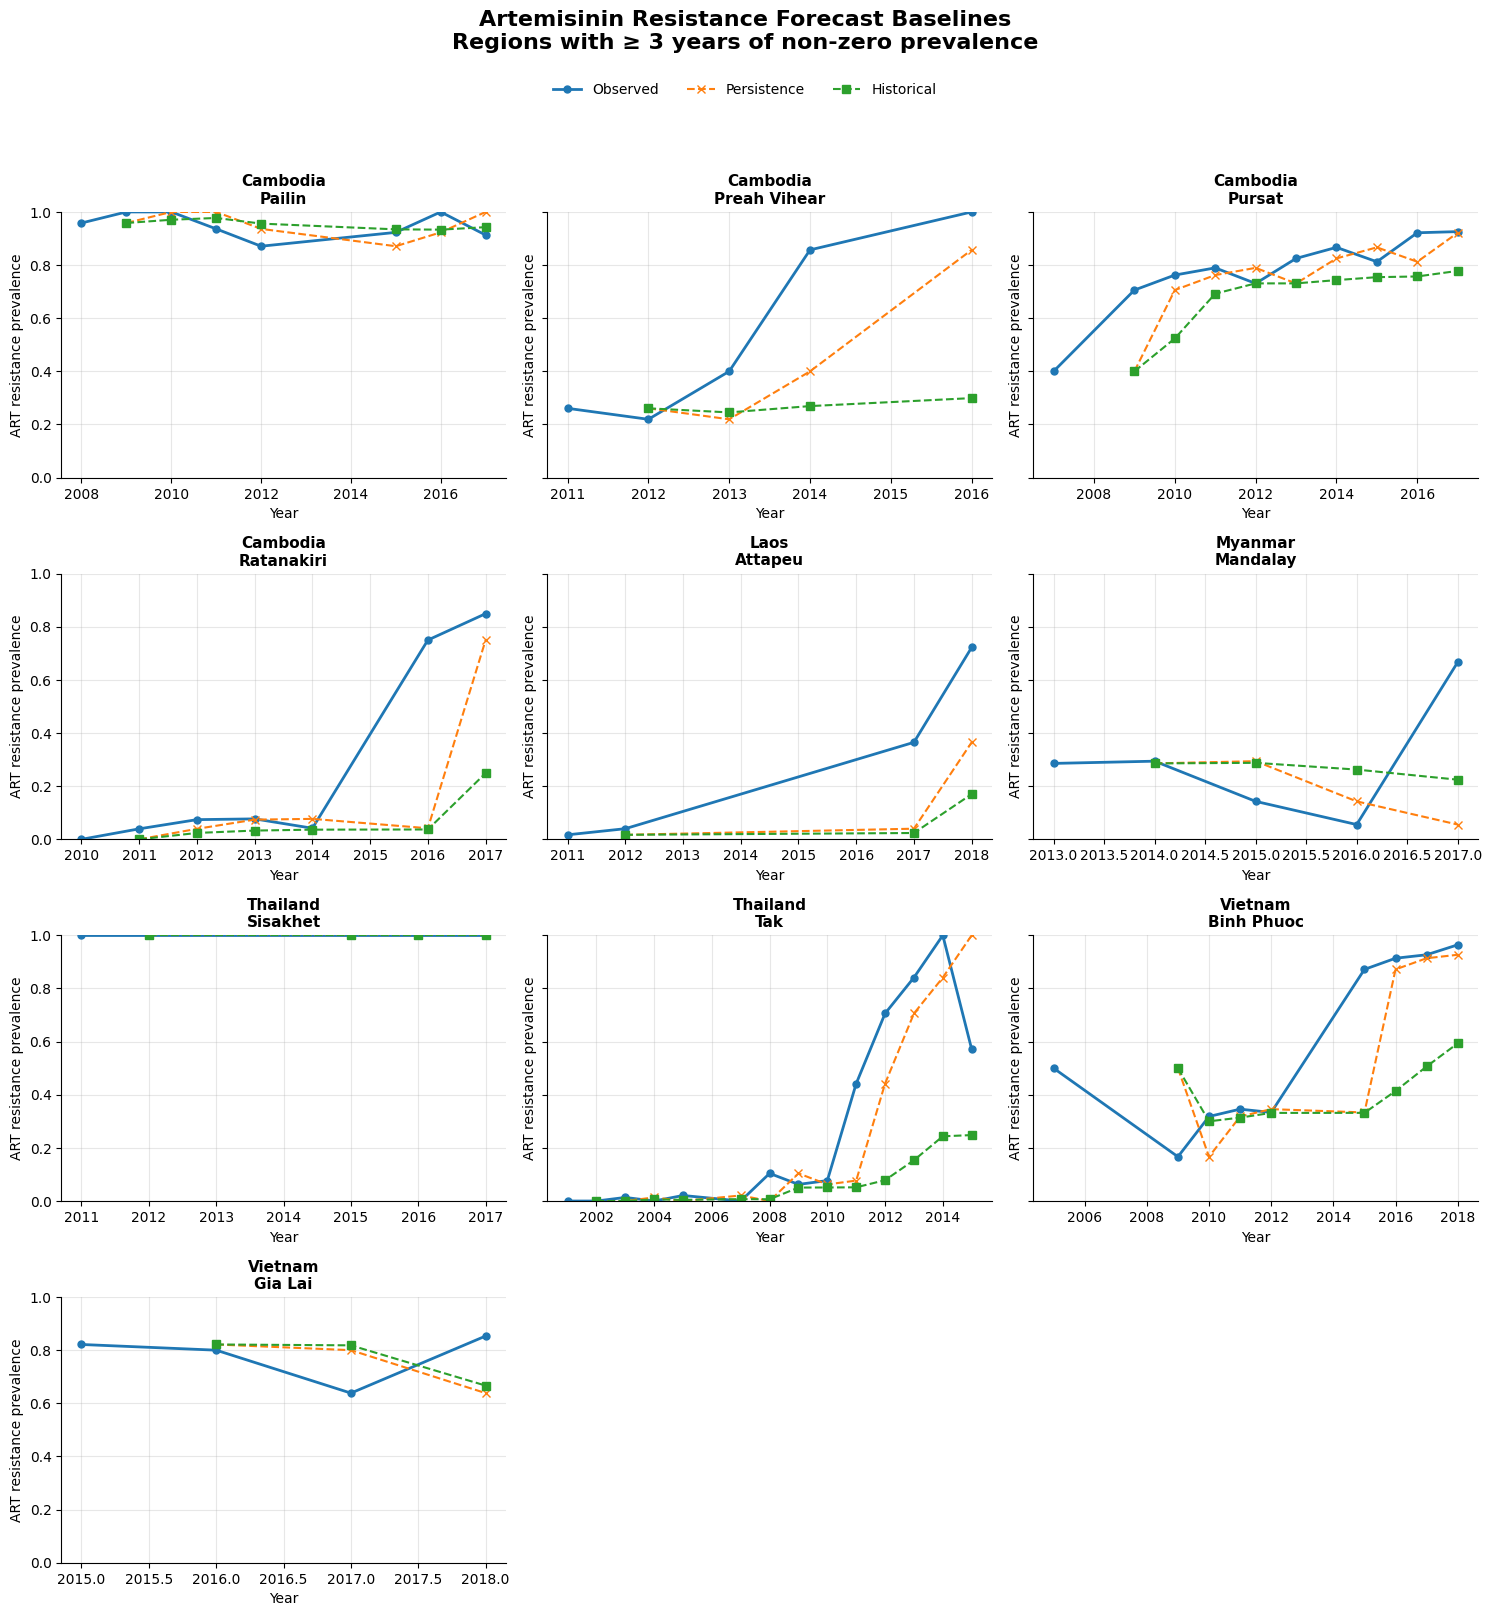

In [31]:
min_data_points = 3

# Collect regions satisfying the filter
selected_regions = []

for (country, admin1), idx in regional_year.groupby(
    ["Country", "Admin level 1"]
).groups.items():

    region_df = regional_year.loc[idx]

    if (region_df["ART_prevalence"] > 0).sum() >= min_data_points:
        selected_regions.append(
            (country, admin1)
        )


print(f"Number of regions plotted: {len(selected_regions)}")


# Grid size
n_regions = len(selected_regions)

n_cols = 3
n_rows = math.ceil(n_regions / n_cols)


fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5*n_cols, 3.8*n_rows),
    sharey=True
)

# Handle single row case
if n_rows == 1:
    axes = axes.reshape(1, -1)

axes = axes.flatten()


for ax, (country, admin1) in zip(
    axes,
    selected_regions
):

    plot_df = regional_year[
        (regional_year["Country"] == country) &
        (regional_year["Admin level 1"] == admin1)
    ].sort_values("Year")


    ax.plot(
        plot_df["Year"],
        plot_df["ART_prevalence"],
        marker="o",
        linewidth=2,
        markersize=5,
        label="Observed"
    )

    ax.plot(
        plot_df["Year"],
        plot_df["persistence_prediction"],
        marker="x",
        linestyle="--",
        linewidth=1.5,
        label="Persistence"
    )

    ax.plot(
        plot_df["Year"],
        plot_df["historical_prediction"],
        marker="s",
        linestyle="--",
        linewidth=1.5,
        label="Historical"
    )
    
    # Remove top and right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


    ax.set_title(
        f"{country}\n{admin1}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Year")
    ax.set_ylabel("ART resistance prevalence")

    ax.set_ylim(0, 1)

    ax.grid(
        True,
        alpha=0.3
    )


# Remove unused axes
for ax in axes[len(selected_regions):]:
    ax.remove()


# Add one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False
)


fig.suptitle(
    f"Artemisinin Resistance Forecast Baselines\n"
    f"Regions with ≥ {min_data_points} years of non-zero prevalence",
    fontsize=16,
    fontweight="bold",
    y=1.06
)


plt.tight_layout()
plt.show()